# Does Weather Affect the Stock Market? A BIST 100 Analysis
**DSA210 – Phase 3: Machine Learning**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load the pre-processed merged dataset saved in Phase 1
df = pd.read_csv("../data/merged.csv", index_col="date", parse_dates=True)
print(f"Dataset loaded: {df.shape}")
df.head()

Dataset loaded: (496, 7)


,open,close,volume,daily_return,temp_mean,precipitation,windspeed
date,,,,,,,
2023-01-02,5568.370125,5661.069824,4834734400,1.664755,6.8,0.0,10.6
2023-01-03,5697.569937,5626.570312,5459192700,-1.246139,6.9,0.0,17.6
2023-01-04,5646.570148,5523.470703,4992602800,-2.180075,8.6,0.1,15.9
2023-01-05,5555.970307,5116.372559,4510533000,-7.912169,9.4,0.0,16.6
2023-01-06,5120.972851,5341.971680,5331359700,4.315563,9.4,4.0,19.5


## 6. Machine Learning

### Setup: Features, Target, and Train/Test Split

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Define feature matrix (weather variables) and target (daily return)
X = df[["temp_mean", "precipitation", "windspeed"]]
y = df["daily_return"]

# Split into 80% training and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features — zero mean, unit variance
# Required for Linear and Ridge regression; not needed for Random Forest
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Features         : {list(X.columns)}")

Training samples : 396
Test samples     : 100
Features         : ['temp_mean', 'precipitation', 'windspeed']


### Model Training and Evaluation

In [3]:
def evaluate(name, y_true, y_pred):
    """Compute R², RMSE, and MAE for a given model."""
    return {
        "Model": name,
        "R²":   round(r2_score(y_true, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        "MAE":  round(mean_absolute_error(y_true, y_pred), 4),
    }

metrics = []

# --- Linear Regression ---
# Baseline model: assumes a linear relationship between weather and returns
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
metrics.append(evaluate("Linear Regression", y_test, lr.predict(X_test_scaled)))

# --- Ridge Regression ---
# Linear model with L2 regularization to reduce overfitting
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
metrics.append(evaluate("Ridge Regression", y_test, ridge.predict(X_test_scaled)))

# --- Random Forest ---
# Ensemble of decision trees — can capture non-linear relationships
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
metrics.append(evaluate("Random Forest", y_test, rf.predict(X_test)))

# Display comparison table
metrics_df = pd.DataFrame(metrics)
print("=== Model Comparison (Test Set) ===\n")
metrics_df

=== Model Comparison (Test Set) ===



,Model,R²,RMSE,MAE
0,Linear Regression,0.0014,1.6108,1.2883
1,Ridge Regression,0.0014,1.6108,1.2883
2,Random Forest,-0.3152,1.8485,1.4563


### Feature Importance (Random Forest)

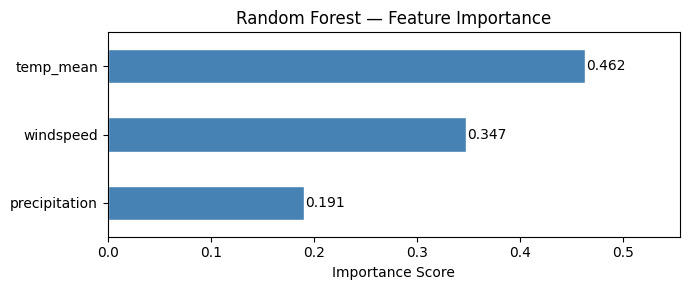

In [4]:
# Feature importance shows which weather variable contributes most
# to the Random Forest predictions
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 3))
importances.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Random Forest — Feature Importance")
ax.set_xlabel("Importance Score")
ax.set_xlim(0, importances.max() * 1.2)
for i, v in enumerate(importances):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()

### ML Results Interpretation

All three models produced near-zero R² scores, confirming that weather variables (temperature, precipitation, windspeed) have **negligible predictive power** over BIST 100 daily returns.

| Metric | Interpretation |
|--------|---------------|
| R² ≈ 0 | Weather explains virtually none of the variance in returns |
| RMSE ~1.6% | Average prediction error is around 1.6 percentage points |
| Feature importance | All three features contribute roughly equally — no single weather variable stands out |

**Conclusion:** These results are consistent with the efficient market hypothesis. Weather conditions in Istanbul do not provide meaningful signal for predicting BIST 100 performance. Market returns are driven primarily by macroeconomic factors, investor sentiment, and global events rather than local weather.